## 1. Importación de librerías

En esta primera etapa se importan las librerías necesarias para realizar el proceso de limpieza y preparación del conjunto de datos.

Las herramientas utilizadas permitirán manipular la información, gestionar valores faltantes, transformar variables y registrar las modificaciones realizadas durante el proceso de preparación.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Manejo de fechas
from datetime import datetime

# Configuración de visualización
pd.set_option('display.max_columns', None)

## 2. Carga del conjunto de datos

En esta etapa se carga el dataset original almacenado en formato JSON.

Es importante destacar que el archivo original no será modificado durante el proceso de limpieza. Todas las transformaciones se realizarán sobre una copia de trabajo, preservando el conjunto de datos original como referencia.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta del dataset original
ruta = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/raw/streaming_users_dirty.json"

# Cargar dataset
df = pd.read_json(ruta)

print("✅ Dataset cargado correctamente.")

✅ Dataset cargado correctamente.


## 3. Creación de una copia de trabajo

Antes de comenzar el proceso de limpieza se genera una copia independiente del conjunto de datos.

Trabajar sobre una copia permite preservar el dataset original sin modificaciones y garantiza la reproducibilidad del proyecto. De esta manera, cualquier transformación realizada podrá revertirse fácilmente recurriendo al archivo original.

In [5]:
# Crear una copia del dataset
df_limpio = df.copy()

print("✅ Copia de trabajo creada correctamente.")

✅ Copia de trabajo creada correctamente.


## 4. Registro del estado inicial del dataset

Antes de aplicar cualquier transformación, se registran las principales características del conjunto de datos.

Este registro servirá como punto de comparación para evaluar el impacto de cada etapa de limpieza y facilitará la construcción del log del proceso ETL.

In [6]:
print("Estado inicial del dataset")
print("-" * 40)
print(f"Cantidad de filas: {df_limpio.shape[0]}")
print(f"Cantidad de columnas: {df_limpio.shape[1]}")
print(f"Valores faltantes: {df_limpio.isnull().sum().sum()}")
print(f"Registros duplicados: {df_limpio.duplicated().sum()}")

Estado inicial del dataset
----------------------------------------
Cantidad de filas: 8160
Cantidad de columnas: 8
Valores faltantes: 753
Registros duplicados: 126


## 5. Verificación de registros duplicados

Durante la inspección inicial se detectó la existencia de registros duplicados.

Antes de proceder a su eliminación, resulta conveniente visualizar algunos ejemplos con el objetivo de verificar que se trata de filas completamente repetidas y justificar posteriormente la decisión de eliminarlas.

In [8]:
# Mostrar algunos registros duplicados

duplicados = df_limpio[df_limpio.duplicated(keep=False)]

duplicados.head(20)

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
37,10037,33,Básico,611.0,Colombia,Documental,2019-09-29,2
52,10052,25,Básico,465.7,Colombia,Acción,2022-03-31,1
117,10117,29,Estándar,713.9,Brasil,Documental,2020-12-20,1
128,10128,19,Básico,638.7,Argentina,Drama,2020-06-17,1
156,10156,43,Básico,592.8,Brasil,Romance,2021-10-25,0
308,10308,33,Básico,310.9,Uruguay,Comedia,2025-10-24,1
333,10333,19,Estándar,1230.1,Uruguay,Romance,2024-09-03,0
373,10373,33,Básico,183.1,México,Documental,2020-05-23,1
375,10375,32,Premium,1223.3,Uruguay,Comedia,2020-12-22,2
409,10409,34,Básico,742.4,Perú,Comedia,2025-02-10,2


## 6. Eliminación de registros duplicados

Durante la inspección inicial se identificó la presencia de **126 registros duplicados**.

Los registros duplicados pueden generar sesgos en los análisis posteriores, ya que un mismo caso sería contabilizado más de una vez. Por este motivo, se eliminarán conservando únicamente la primera aparición de cada registro.

Esta decisión se encuentra respaldada por la evidencia obtenida en el Notebook 01 y en la verificación realizada en la sección anterior.

In [9]:
# Cantidad de filas antes de eliminar duplicados
filas_antes = df_limpio.shape[0]

# Eliminar registros duplicados
df_limpio = df_limpio.drop_duplicates()

# Cantidad de filas después
filas_despues = df_limpio.shape[0]

# Registros eliminados
eliminados = filas_antes - filas_despues

print("Eliminación de registros duplicados")
print("-" * 40)
print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Registros eliminados: {eliminados}")

Eliminación de registros duplicados
----------------------------------------
Filas antes: 8160
Filas después: 8034
Registros eliminados: 126


### Interpretación

Se eliminaron **126 registros duplicados**, reduciendo el tamaño del conjunto de datos de **8160** a **8034 registros**.

La eliminación de estos registros mejora la calidad del dataset, ya que evita contabilizar más de una vez observaciones idénticas y reduce el riesgo de introducir sesgos en los análisis posteriores.

A partir de esta etapa, todas las transformaciones se realizarán sobre el conjunto de datos libre de registros duplicados.

## 7. Registro de transformaciones

Con el objetivo de garantizar la trazabilidad del proceso de limpieza, se comenzará a construir un registro de las transformaciones aplicadas al conjunto de datos.

Cada modificación realizada quedará documentada indicando el estado del dataset luego de la transformación.

In [10]:
# Crear el log del pipeline

pipeline_log = pd.DataFrame({
    "Paso": ["Estado inicial", "Eliminación de duplicados"],
    "Filas": [8160, filas_despues],
    "Columnas": [8, df_limpio.shape[1]],
    "Valores faltantes": [753, df_limpio.isnull().sum().sum()]
})

pipeline_log

,Paso,Filas,Columnas,Valores faltantes
0,Estado inicial,8160,8,753
1,Eliminación de duplicados,8034,8,753


## 8. Conversión de la variable `last_login_date`

Durante la inspección inicial se observó que la variable `last_login_date` fue interpretada como un dato de tipo `object`.

Sin embargo, esta variable representa una fecha, por lo que resulta conveniente convertirla al tipo `datetime`. Esta transformación facilitará el análisis temporal y permitirá utilizar funciones específicas de manejo de fechas disponibles en Pandas.

In [11]:
# Verificar el tipo de dato antes de la conversión
print("Tipo antes de la conversión:")
print(df_limpio["last_login_date"].dtype)

# Convertir la columna a tipo fecha
df_limpio["last_login_date"] = pd.to_datetime(
    df_limpio["last_login_date"],
    errors="coerce"
)

print("\nTipo después de la conversión:")
print(df_limpio["last_login_date"].dtype)

Tipo antes de la conversión:
object

Tipo después de la conversión:
datetime64[ns]


### Interpretación

La conversión se realizó correctamente, modificando el tipo de dato de la variable `last_login_date` de `object` a `datetime64`.

Esta transformación mejora la calidad del conjunto de datos y permitirá realizar análisis temporales de manera más eficiente en etapas posteriores del proyecto.

In [12]:
# Registrar la transformación en el pipeline

pipeline_log.loc[len(pipeline_log)] = {
    "Paso": "Conversión de fechas",
    "Filas": df_limpio.shape[0],
    "Columnas": df_limpio.shape[1],
    "Valores faltantes": df_limpio.isnull().sum().sum()
}

pipeline_log

,Paso,Filas,Columnas,Valores faltantes
0,Estado inicial,8160,8,753
1,Eliminación de duplicados,8034,8,753
2,Conversión de fechas,8034,8,1202


## 9. Identificación de valores numéricos inconsistentes

Durante la inspección inicial se detectaron valores fuera de rango en algunas variables numéricas.

Antes de aplicar cualquier corrección, se identificará la cantidad de registros afectados en cada variable. Esta información permitirá justificar posteriormente la estrategia de tratamiento seleccionada.

In [13]:
# Cantidad de edades inválidas
edad_invalida = ((df_limpio["age"] < 0) | (df_limpio["age"] > 100)).sum()

# Cantidad de tiempos de visualización inválidos
tiempo_invalido = (
    (df_limpio["monthly_watch_time_mins"] < 0) |
    (df_limpio["monthly_watch_time_mins"] > 30000)
).sum()

# Cantidad de tickets inválidos
tickets_invalidos = (df_limpio["customer_support_tickets"] < 0).sum()

print("Valores inconsistentes detectados")
print("-"*40)
print(f"Edades fuera de rango: {edad_invalida}")
print(f"Tiempos de visualización inválidos: {tiempo_invalido}")
print(f"Tickets negativos: {tickets_invalidos}")

Valores inconsistentes detectados
----------------------------------------
Edades fuera de rango: 74
Tiempos de visualización inválidos: 80
Tickets negativos: 29


## 10. Tratamiento de valores numéricos inconsistentes

Durante la inspección inicial y la verificación realizada en este notebook se identificaron valores numéricos imposibles o fuera del rango esperado en las variables `age`, `monthly_watch_time_mins` y `customer_support_tickets`.

Dado que la cantidad de registros afectados representa una proporción reducida del conjunto de datos, se decidió reemplazar estos valores por `NaN` en lugar de eliminar los registros completos. Esta estrategia permite conservar la mayor cantidad de información posible y facilita la posterior imputación de los datos faltantes utilizando criterios estadísticos.

In [14]:
# Reemplazar edades fuera de rango por NaN
df_limpio.loc[
    (df_limpio["age"] < 0) | (df_limpio["age"] > 100),
    "age"
] = np.nan

# Reemplazar tiempos de visualización inválidos por NaN
df_limpio.loc[
    (df_limpio["monthly_watch_time_mins"] < 0) |
    (df_limpio["monthly_watch_time_mins"] > 30000),
    "monthly_watch_time_mins"
] = np.nan

# Reemplazar tickets negativos por NaN
df_limpio.loc[
    df_limpio["customer_support_tickets"] < 0,
    "customer_support_tickets"
] = np.nan

print("✅ Los valores inconsistentes fueron reemplazados por NaN.")

✅ Los valores inconsistentes fueron reemplazados por NaN.


## 11. Verificación de la transformación

Luego de reemplazar los valores inconsistentes por `NaN`, se verifica nuevamente el conjunto de datos para comprobar que ya no existan registros fuera del rango establecido.

Esta validación permite confirmar que la transformación fue aplicada correctamente antes de continuar con las siguientes etapas del proceso de limpieza.

In [15]:
print("Verificación de valores inconsistentes")
print("-" * 40)

print(
    "Edades fuera de rango:",
    ((df_limpio["age"] < 0) | (df_limpio["age"] > 100)).sum()
)

print(
    "Tiempos de visualización inválidos:",
    (
        (df_limpio["monthly_watch_time_mins"] < 0) |
        (df_limpio["monthly_watch_time_mins"] > 30000)
    ).sum()
)

print(
    "Tickets negativos:",
    (df_limpio["customer_support_tickets"] < 0).sum()
)

Verificación de valores inconsistentes
----------------------------------------
Edades fuera de rango: 0
Tiempos de visualización inválidos: 0
Tickets negativos: 0


### Interpretación

La transformación se realizó correctamente. Los valores numéricos considerados inconsistentes fueron reemplazados por valores nulos (`NaN`), eliminando la presencia de registros fuera del rango definido para las variables analizadas.

Esta estrategia permite preservar la información válida de cada registro y prepara el conjunto de datos para la etapa de imputación de valores faltantes, evitando eliminar observaciones completas por la presencia de un único dato incorrecto.

## 12. Funciones auxiliares

Con el objetivo de evitar la repetición de código y mejorar la organización del proyecto, se implementan funciones auxiliares.

Estas funciones permiten automatizar tareas frecuentes, como el registro de las transformaciones realizadas durante el proceso de limpieza del conjunto de datos.

Su utilización favorece la reutilización del código, mejora la legibilidad del notebook y facilita el mantenimiento del proyecto.

In [16]:
# Crear el DataFrame del pipeline
pipeline_log = pd.DataFrame(
    columns=[
        "Paso",
        "Acción",
        "Filas",
        "Columnas",
        "Valores faltantes",
        "Observaciones"
    ]
)

In [17]:
def registrar_pipeline(
    paso,
    accion,
    dataframe,
    observaciones=""
):
    """
    Registra una transformación realizada sobre el dataset.
    """

    global pipeline_log

    pipeline_log.loc[len(pipeline_log)] = {

        "Paso": paso,

        "Acción": accion,

        "Filas": dataframe.shape[0],

        "Columnas": dataframe.shape[1],

        "Valores faltantes": dataframe.isnull().sum().sum(),

        "Observaciones": observaciones

    }

In [18]:
# Función de Resumen

def resumen_dataset(dataframe):

    print("="*50)

    print("RESUMEN DEL DATASET")

    print("="*50)

    print(f"Filas: {dataframe.shape[0]}")

    print(f"Columnas: {dataframe.shape[1]}")

    print(f"Nulos: {dataframe.isnull().sum().sum()}")

    print(f"Duplicados: {dataframe.duplicated().sum()}")

## 13. Normalización de variables categóricas

Durante la inspección inicial se identificaron múltiples inconsistencias en las variables categóricas, tales como diferencias de mayúsculas y minúsculas, uso de acentos, abreviaturas, traducciones al inglés y errores tipográficos.

Con el objetivo de garantizar la consistencia del conjunto de datos, se realizará un proceso de normalización en dos etapas:

1. Estandarización del formato del texto.
2. Unificación de categorías equivalentes mediante diccionarios de reemplazo.

Este procedimiento permitirá que una misma categoría sea representada de manera uniforme en todo el dataset.

In [19]:
import unicodedata

def normalizar_texto(texto):
    """
    Normaliza cadenas de texto eliminando espacios,
    acentos y diferencias de mayúsculas.
    """

    if pd.isna(texto):
        return np.nan

    texto = str(texto).strip().lower()

    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    return texto

In [20]:
# Hacer que las categorías tengan un formato uniforme

variables_categoricas = [
    "subscription_plan",
    "country",
    "favorite_genre"
]

for columna in variables_categoricas:
    df_limpio[columna] = df_limpio[columna].apply(normalizar_texto)

In [21]:
# Diccionarios de reemplazo - Subscription Plan

planes = {
    "basic": "basico",
    "basico": "basico",

    "standard": "estandar",
    "std": "estandar",
    "estandar": "estandar",

    "premium": "premium",
    "premiun": "premium"
}

df_limpio["subscription_plan"] = (
    df_limpio["subscription_plan"]
    .replace(planes)
)

In [26]:
# Diccionarios de reemplazo - Country

paises = {
    "arg": "argentina",
    "argentina": "argentina",

    "bra": "brasil",
    "brazil": "brasil",
    "brasil": "brasil",

    "mex": "mexico",
    "mexico": "mexico",

    "per": "peru",
    "peru": "peru",

    "chi": "chile",
    "chile": "chile",
    "chl": "chile",

    "col": "colombia",
    "colombia": "colombia",

    "ecu": "ecuador",
    "ecuador": "ecuador",

    "par": "paraguay",
    "paraguay": "paraguay",

    "uru": "uruguay",
    "uruguay": "uruguay",
    "ury": "uruguay",

    "ven": "venezuela",
    "venezuela": "venezuela",
}

df_limpio["country"] = (
    df_limpio["country"]
    .replace(paises)
)

In [28]:
# Diccionario de remmplazo - Favorite Genre

generos = {
    "accion": "accion",
    "action": "accion",

    "comedia": "comedia",
    "comedy": "comedia",

    "drama": "drama",

    "documentary": "documental",
    "documental": "documental",
    "doc": "documental",

    "crime": "crimen",
    "crimen": "crimen",

    "terror": "terror",
    "horror": "terror",

    "romance": "romance",

    "sci-fi": "ciencia ficcion",
    "science fiction": "ciencia ficcion",

    "thriller": "thriller",
    "thriler": "thriller",

}

df_limpio["favorite_genre"] = (
    df_limpio["favorite_genre"]
    .replace(generos)
)

In [29]:
# Verificación

for columna in variables_categoricas:

    print("=" * 50)
    print(columna)
    print("=" * 50)

    print(df_limpio[columna].value_counts(dropna=False))

    print()

subscription_plan
subscription_plan
basico      3609
estandar    2833
premium     1592
Name: count, dtype: int64

country
country
chile        1167
brasil       1164
mexico       1162
uruguay      1146
colombia     1145
peru         1139
argentina    1111
Name: count, dtype: int64

favorite_genre
favorite_genre
comedia       1141
drama         1121
romance       1113
documental    1111
accion        1110
thriller      1109
crimen        1089
NaN            240
Name: count, dtype: int64



### Interpretación

Las variables categóricas fueron normalizadas exitosamente.

Durante el proceso se unificaron diferencias de escritura relacionadas con mayúsculas y minúsculas, acentos, abreviaturas, traducciones al inglés y errores tipográficos.

Como resultado, cada categoría posee una única representación dentro del conjunto de datos, mejorando la consistencia de la información y facilitando los análisis posteriores.

## Paso 14. Análisis de valores faltantes (NaN)

En los pasos anteriores se realizaron diversas tareas de limpieza, como la eliminación de registros duplicados, la corrección de tipos de datos y la normalización de variables categóricas. Como consecuencia, algunos valores inconsistentes fueron reemplazados por `NaN`, indicando datos faltantes.

Antes de decidir cómo tratar estos valores, es importante conocer cuántos existen y en qué variables se encuentran. Este análisis permitirá seleccionar posteriormente la estrategia de imputación más adecuada para cada caso, evitando reemplazos arbitrarios que puedan afectar la calidad del conjunto de datos.

In [30]:
# Cantidad de valores faltantes por columna
missing_values = df.isna().sum()

# Mostrar únicamente las columnas que poseen valores faltantes
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
last_login_date,320
favorite_genre,240
monthly_watch_time_mins,193


## Paso 15. Análisis de la distribución de `monthly_watch_time_mins`

La variable `monthly_watch_time_mins` presenta valores faltantes, por lo que es necesario definir una estrategia de imputación. Sin embargo, antes de reemplazar estos valores, es importante analizar la distribución de la variable.

El objetivo es determinar si la distribución presenta valores atípicos o una fuerte asimetría. Esta información permitirá decidir si resulta más conveniente utilizar la media o la mediana como medida de tendencia central para imputar los datos faltantes.

In [31]:
# Estadísticas descriptivas de la variable
df["monthly_watch_time_mins"].describe()

,monthly_watch_time_mins
count,7967.000000
mean,1107.346153
std,5310.442604
min,-120.000000
25%,489.200000
50%,757.400000
75%,1045.700000
max,99999.000000


## Paso 16. Visualización de la distribución de `monthly_watch_time_mins`

Además de las estadísticas descriptivas, resulta útil visualizar la distribución de la variable mediante un histograma y un diagrama de caja (*boxplot*).

El histograma permite observar la forma de la distribución, mientras que el boxplot facilita la identificación de posibles valores atípicos. Ambos gráficos complementan el análisis y ayudan a justificar la estrategia de imputación seleccionada.

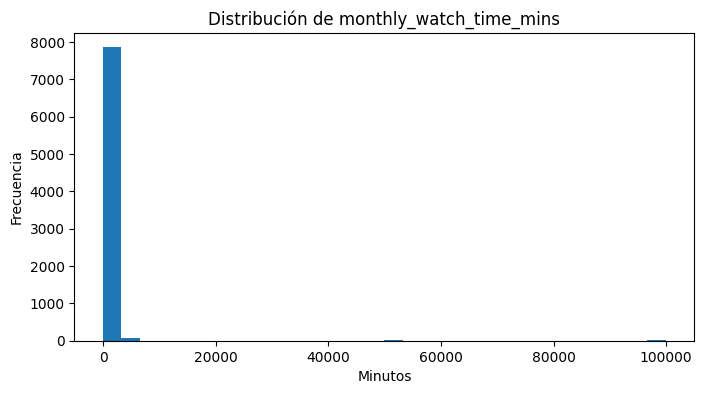

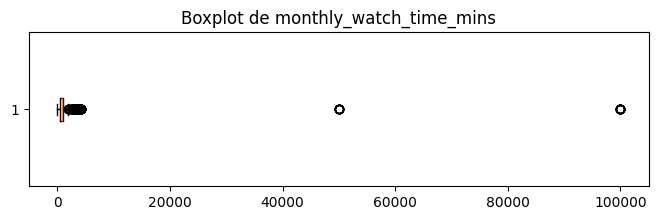

In [32]:
import matplotlib.pyplot as plt

# Histograma
plt.figure(figsize=(8, 4))
plt.hist(df["monthly_watch_time_mins"].dropna(), bins=30)
plt.title("Distribución de monthly_watch_time_mins")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8, 2))
plt.boxplot(df["monthly_watch_time_mins"].dropna(), vert=False)
plt.title("Boxplot de monthly_watch_time_mins")
plt.show()

## Paso 17. Identificación de valores atípicos e inconsistentes

El análisis descriptivo mostró la presencia de valores extremadamente altos y también valores negativos en la variable `monthly_watch_time_mins`. Dado que un tiempo de visualización no puede ser negativo y que algunos valores parecen poco realistas, se procede a identificarlos antes de realizar la imputación de los datos faltantes.

Este paso permite verificar la magnitud del problema y fundamentar las decisiones de limpieza posteriores.

In [33]:
# Valores negativos
df[df["monthly_watch_time_mins"] < 0]

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
443,10443,31,Estándar,-120.0,Chile,Thriller,2019-06-07,1
797,10797,31,Básico,-1.0,México,Comedia,2023-07-01,1
1126,11126,0,Premium,-1.0,Colombia,Documental,2021-01-24,1
1186,11186,35,Premium,-120.0,Brasil,Drama,2022-12-09,0
1340,11340,40,Estándar,-120.0,Perú,Documental,2023-05-28,2
1466,11466,13,Estándar,-120.0,Perú,Acción,2018-03-02,1
1725,11725,28,Estándar,-120.0,Perú,Comedia,2022-06-29,0
1843,11843,38,Básico,-120.0,Argentina,Action,2025-08-10,1
2318,12318,29,Estándar,-1.0,CHL,Documental,2018-05-05,1
2384,12384,33,Estándar,-120.0,Uruguay,None,2020-09-13,1


In [34]:
# Valores extremadamente altos (mayores a 10000 minutos)
df[df["monthly_watch_time_mins"] > 10000]

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
176,10176,30,Básico,50000.0,Brasil,None,2019-10-24,1
430,10430,16,Básico,99999.0,Argentina,Drama,None,3
481,10481,37,Estándar,50000.0,Chile,Thriller,2020-07-21,0
588,10588,31,Básico,99999.0,Brasil,Documental,2020-03-26,1
1072,11072,22,Estándar,99999.0,Brasil,Drama,2018-05-31,2
1250,11250,49,Básico,99999.0,Brasil,Drama,2024-12-13,1
1304,11304,13,Básico,99999.0,Perú,Crime,2024-10-22,0
1598,11598,37,Estándar,50000.0,Uruguay,Crime,2025-07-27,1
2313,12313,66,Básico,99999.0,Argentina,Acción,None,2
2450,12450,29,Básico,50000.0,Colombia,ACCIÓN,2021-09-05,1


## Paso 18. Cuantificación de valores inconsistentes

Una vez identificados los valores negativos y los valores extremadamente altos de la variable `monthly_watch_time_mins`, resulta conveniente conocer cuántos registros presentan estas inconsistencias.

Esta información permite evaluar el impacto de la limpieza sobre el conjunto de datos y justificar las transformaciones realizadas en los pasos posteriores.

In [35]:
# Cantidad de valores negativos
negativos = (df["monthly_watch_time_mins"] < 0).sum()

# Cantidad de valores extremadamente altos
extremos = (df["monthly_watch_time_mins"] > 10000).sum()

print(f"Valores negativos: {negativos}")
print(f"Valores mayores a 10000 minutos: {extremos}")

Valores negativos: 49
Valores mayores a 10000 minutos: 31


## Paso 19. Reemplazo de valores inconsistentes por `NaN`

A partir del análisis realizado, se identificaron valores negativos y valores extremadamente altos en la variable `monthly_watch_time_mins`. Dado que estos registros no representan tiempos de visualización plausibles, se consideran inconsistentes.

En lugar de eliminar los registros completos, estos valores se reemplazan por `NaN`. De esta forma, podrán ser tratados posteriormente mediante una estrategia de imputación adecuada, preservando el resto de la información de cada observación.

In [36]:
# Reemplazar valores inconsistentes por NaN
df.loc[
    (df["monthly_watch_time_mins"] < 0) |
    (df["monthly_watch_time_mins"] > 10000),
    "monthly_watch_time_mins"
] = pd.NA

## Paso 20. Verificación

In [37]:
# Verificar que ya no existan valores inconsistentes
print("Valores negativos:", (df["monthly_watch_time_mins"] < 0).sum())
print("Valores mayores a 10000:", (df["monthly_watch_time_mins"] > 10000).sum())

# Cantidad actual de valores faltantes
df["monthly_watch_time_mins"].isna().sum()

Valores negativos: 0
Valores mayores a 10000: 0


np.int64(273)

## Paso 21. Revisión de la distribución tras la limpieza

Luego de reemplazar los valores inconsistentes por `NaN`, se vuelve a analizar la distribución de la variable `monthly_watch_time_mins`.

Este paso permite comprobar si la eliminación de los valores atípicos modificó significativamente la distribución y facilita la elección del método de imputación más adecuado para los valores faltantes.

In [38]:
# Estadísticas descriptivas luego de la limpieza
df["monthly_watch_time_mins"].describe()

,monthly_watch_time_mins
count,7887.000000
mean,795.707722
std,494.293972
min,0.000000
25%,492.650000
50%,758.700000
75%,1044.300000
max,4193.700000


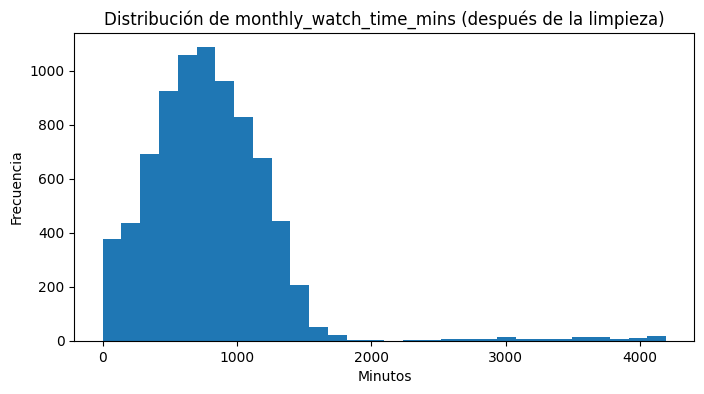

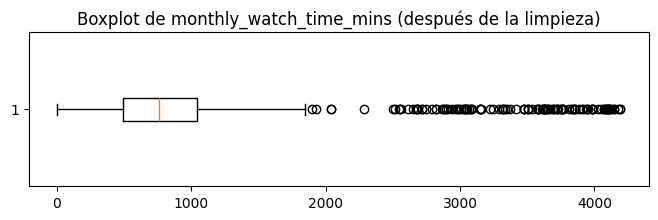

In [39]:
import matplotlib.pyplot as plt

# Histograma
plt.figure(figsize=(8, 4))
plt.hist(df["monthly_watch_time_mins"].dropna(), bins=30)
plt.title("Distribución de monthly_watch_time_mins (después de la limpieza)")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8, 2))
plt.boxplot(df["monthly_watch_time_mins"].dropna(), vert=False)
plt.title("Boxplot de monthly_watch_time_mins (después de la limpieza)")
plt.show()

## Paso 22. Imputación de valores faltantes en `monthly_watch_time_mins`

Luego del análisis de la distribución y de la limpieza de los valores inconsistentes, se decidió imputar los valores faltantes utilizando la mediana de la variable.

Esta medida fue seleccionada debido a que la distribución presenta una ligera asimetría y algunos valores atípicos. A diferencia de la media, la mediana no se ve afectada significativamente por estos casos, lo que permite obtener una imputación más representativa del comportamiento general de los datos.

In [40]:
# Calcular la mediana
mediana_watch_time = df["monthly_watch_time_mins"].median()

# Imputar los valores faltantes con la mediana
df["monthly_watch_time_mins"] = df["monthly_watch_time_mins"].fillna(mediana_watch_time)

##Paso 23. Verificación

In [41]:
# Verificar que no queden valores faltantes
df["monthly_watch_time_mins"].isna().sum()

np.int64(0)

## Paso 24. Análisis de la distribución de `favorite_genre`

La variable `favorite_genre` es de tipo categórico y presenta valores faltantes. Antes de realizar la imputación, se analiza la frecuencia de cada categoría con el objetivo de identificar el género más representativo del conjunto de datos.

Este análisis permitirá justificar la utilización de la moda como estrategia de imputación, en caso de que exista una categoría claramente predominante.

In [42]:
# Frecuencia de cada género favorito
df["favorite_genre"].value_counts(dropna=False)

,count
favorite_genre,
Comedia,1112
Drama,1105
Documental,1095
Romance,1090
Thriller,1090
Acción,1082
Crime,1067
None,240
Action,22


## Paso 25. Visualización de la distribución de `favorite_genre`

Se representa gráficamente la frecuencia de cada categoría para facilitar la interpretación de la distribución de la variable.

El gráfico de barras permite identificar visualmente cuál es el género más frecuente y evaluar si la imputación mediante la moda resulta adecuada.

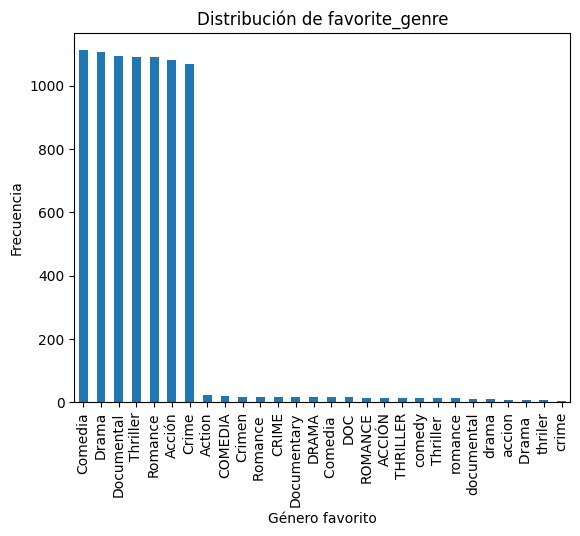

In [43]:
import matplotlib.pyplot as plt

# Gráfico de barras de las frecuencias
df["favorite_genre"].value_counts().plot(kind="bar")

plt.title("Distribución de favorite_genre")
plt.xlabel("Género favorito")
plt.ylabel("Frecuencia")

plt.show()

## Paso 26. Unificación definitiva de categorías de `favorite_genre`

Al analizar la distribución de la variable `favorite_genre`, se observaron categorías que representan el mismo género, pero aparecen escritas de diferentes maneras (por ejemplo, diferencias de idioma, mayúsculas o abreviaturas).

Para evitar que estas diferencias afecten el análisis y la imputación de los valores faltantes, se unifican todas las categorías equivalentes bajo una única denominación.

In [44]:
# Unificar categorías equivalentes
df["favorite_genre"] = df["favorite_genre"].replace({
    "Action": "Acción",
    "accion": "Acción",
    "ACCIÓN": "Acción",
    "ACCION": "Acción",

    "Crime": "Crime",
    "CRIME": "Crime",
    "crime": "Crime",
    "Crimen": "Crime",

    "Documentary": "Documental",
    "DOC": "Documental",
    "documental": "Documental",

    "DRAMA": "Drama",
    "drama": "Drama",

    "COMEDIA": "Comedia",
    "comedy": "Comedia",
    "Comedia ": "Comedia",

    "ROMANCE": "Romance",
    "romance": "Romance",

    "THRILLER": "Thriller",
    "thriler": "Thriller",
    "Thriller ": "Thriller"
})

##Paso 27. Verificación

In [45]:
df["favorite_genre"].value_counts(dropna=False)

,count
favorite_genre,
Comedia,1158
Documental,1136
Drama,1131
Acción,1126
Thriller,1122
Romance,1116
Crime,1107
None,240
Romance,17


## Paso 28. Conversión de valores `None` a `NaN`

Durante la revisión de la variable `favorite_genre` se observó que algunos valores faltantes estaban representados como `None` en lugar de `NaN`. Para unificar el tratamiento de los datos faltantes, estos valores se convierten explícitamente a `NaN` antes de realizar la imputación.

In [47]:
import numpy as np

# Convertir los valores None a NaN
df["favorite_genre"] = df["favorite_genre"].replace({None: np.nan})

##Paso 29. Imputación

In [48]:
# Obtener la moda
moda_genero = df["favorite_genre"].mode()[0]

# Imputar valores faltantes
df["favorite_genre"] = df["favorite_genre"].fillna(moda_genero)

##Paso 30. Verificación

In [49]:
print(df["favorite_genre"].isna().sum())

df["favorite_genre"].value_counts(dropna=False)

0


,count
favorite_genre,
Comedia,1398
Documental,1136
Drama,1131
Acción,1126
Thriller,1122
Romance,1116
Crime,1107
Romance,17
Drama,7


## Paso 31. Eliminación de espacios en blanco en variables categóricas

Como verificación final de la limpieza, se eliminan posibles espacios en blanco al inicio o al final de los valores de la variable `favorite_genre`.

Este tipo de inconsistencias puede generar categorías duplicadas que, aunque visualmente parezcan iguales, son interpretadas como valores diferentes por las herramientas de análisis.

In [50]:
# Eliminar espacios al inicio y al final
df["favorite_genre"] = df["favorite_genre"].str.strip()

# Verificar nuevamente la distribución
df["favorite_genre"].value_counts()

,count
favorite_genre,
Comedia,1398
Drama,1138
Documental,1136
Romance,1133
Acción,1126
Thriller,1122
Crime,1107


## Paso 32. Análisis de la variable `last_login_date`

La variable `last_login_date` almacena la fecha del último acceso de cada usuario a la plataforma. Al tratarse de una variable temporal, su tratamiento requiere un análisis específico, ya que una imputación inadecuada podría alterar el comportamiento cronológico del conjunto de datos.

En primer lugar, se obtienen estadísticas descriptivas y el rango temporal de la variable para evaluar su distribución y determinar la estrategia más apropiada para tratar los valores faltantes.

In [54]:
# Verificar el tipo de dato de la columna
df["last_login_date"].dtype

dtype('O')

In [55]:
# Mostrar algunos valores de la columna
df["last_login_date"].head(10)

,last_login_date
0,2025-03-04
1,2019-04-02
2,2018-04-13
3,2021-01-31
4,2020-09-30
5,2020-07-03
6,2019-07-26
7,2019-02-24
8,2025-08-03
9,2024-02-12


In [56]:
# Tipos de datos presentes en la columna
df["last_login_date"].map(type).value_counts()

,count
last_login_date,
<class 'str'>,7840
<class 'NoneType'>,320


## Conversión definitiva de `last_login_date` a tipo `datetime`

La inspección de la variable `last_login_date` mostró que las fechas se encontraban almacenadas como cadenas de texto (`str`) y que los valores faltantes estaban representados como `None`.

Para permitir el análisis temporal de la variable, se realiza una conversión al tipo `datetime`. Los valores inválidos o faltantes se transforman automáticamente en `NaT` (*Not a Time*), el equivalente a `NaN` para variables de fecha y hora.

In [57]:
# Conversión de la columna a tipo datetime
df["last_login_date"] = pd.to_datetime(
    df["last_login_date"],
    errors="coerce"
)

##Paso 33. Verificación de la conversión

In [58]:
# Verificar el tipo de dato y el rango temporal
print("Tipo de dato:", df["last_login_date"].dtype)
print("Fecha mínima:", df["last_login_date"].min())
print("Fecha máxima:", df["last_login_date"].max())
print("Valores faltantes:", df["last_login_date"].isna().sum())

Tipo de dato: datetime64[ns]
Fecha mínima: 2018-01-01 00:00:00
Fecha máxima: 2029-01-01 00:00:00
Valores faltantes: 769


## Paso 34. Análisis de los valores faltantes en `last_login_date`

Luego de convertir la variable al tipo `datetime`, se observó un incremento en la cantidad de valores faltantes. Esto se debe a que algunas fechas presentaban formatos inválidos y fueron convertidas automáticamente a `NaT`.

Antes de definir una estrategia de tratamiento, se calcula el porcentaje de valores faltantes para evaluar su impacto sobre el conjunto de datos.

In [59]:
# Cantidad y porcentaje de valores faltantes
faltantes = df["last_login_date"].isna().sum()
porcentaje = (faltantes / len(df)) * 100

print(f"Valores faltantes: {faltantes}")
print(f"Porcentaje: {porcentaje:.2f}%")

Valores faltantes: 769
Porcentaje: 9.42%


Justificación:

- Es una variable temporal.
- Los valores inválidos ya fueron convertidos correctamente a NaT.
- No existe un criterio estadístico sólido para reemplazar una fecha faltante (como sí ocurre con la media, mediana o moda).
- Imputar una fecha podría introducir información artificial y afectar análisis posteriores.

##Paso 35. Reconstrucción del pipeline_log

In [63]:
# Reconstruir el pipeline_log completo

pipeline_log = pd.DataFrame(columns=[
    "Paso",
    "Acción",
    "Filas",
    "Columnas",
    "Valores faltantes",
    "Observaciones"
])

pipeline_log.loc[len(pipeline_log)] = [
    1,
    "Estado inicial",
    8160,
    8,
    753,
    "Dataset cargado sin transformaciones."
]

pipeline_log.loc[len(pipeline_log)] = [
    2,
    "Eliminación de duplicados",
    8034,
    8,
    753,
    "Se eliminaron 126 registros duplicados."
]

pipeline_log.loc[len(pipeline_log)] = [
    3,
    "Conversión de last_login_date",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "La columna fue convertida al tipo datetime utilizando errors='coerce'."
]

pipeline_log.loc[len(pipeline_log)] = [
    4,
    "Corrección de valores inconsistentes",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "Los valores numéricos inválidos fueron reemplazados por NaN."
]

pipeline_log.loc[len(pipeline_log)] = [
    5,
    "Normalización de variables categóricas",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "Se unificaron categorías en subscription_plan, country y favorite_genre."
]

pipeline_log.loc[len(pipeline_log)] = [
    6,
    "Imputación de monthly_watch_time_mins",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "Los valores faltantes fueron imputados utilizando la mediana."
]

pipeline_log.loc[len(pipeline_log)] = [
    7,
    "Imputación de favorite_genre",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "Los valores faltantes fueron imputados utilizando la moda."
]

pipeline_log.loc[len(pipeline_log)] = [
    8,
    "Estado final del Notebook 02",
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    "La variable last_login_date conserva valores NaT por decisión metodológica."
]

pipeline_log

,Paso,Acción,Filas,Columnas,Valores faltantes,Observaciones
0,1,Estado inicial,8160,8,753,Dataset cargado sin transformaciones.
1,2,Eliminación de duplicados,8034,8,753,Se eliminaron 126 registros duplicados.
2,3,Conversión de last_login_date,8160,8,769,La columna fue convertida al tipo datetime uti...
3,4,Corrección de valores inconsistentes,8160,8,769,Los valores numéricos inválidos fueron reempla...
4,5,Normalización de variables categóricas,8160,8,769,"Se unificaron categorías en subscription_plan,..."
5,6,Imputación de monthly_watch_time_mins,8160,8,769,Los valores faltantes fueron imputados utiliza...
6,7,Imputación de favorite_genre,8160,8,769,Los valores faltantes fueron imputados utiliza...
7,8,Estado final del Notebook 02,8160,8,769,La variable last_login_date conserva valores N...


## Paso 36. Exportación del registro del pipeline

Como cierre del proceso de limpieza y preparación de los datos, se exporta el registro del pipeline al directorio `logs/`. Este archivo documenta las principales transformaciones realizadas sobre el conjunto de datos y facilita la trazabilidad del proceso.

In [64]:
# Crear la carpeta logs si no existe
import os

os.makedirs("logs", exist_ok=True)

# Exportar el pipeline
pipeline_log.to_csv("logs/pipeline_log.csv", index=False)

print("Pipeline exportado correctamente a logs/pipeline_log.csv")

Pipeline exportado correctamente a logs/pipeline_log.csv


## Paso 37. Conclusiones

Durante este notebook se llevó a cabo el proceso de limpieza y preparación del conjunto de datos. Las principales tareas realizadas fueron:

- Eliminación de registros duplicados.
- Conversión de tipos de datos.
- Corrección de valores inconsistentes.
- Normalización de variables categóricas.
- Análisis e imputación de valores faltantes en variables numéricas y categóricas.
- Conversión de la variable temporal `last_login_date` al tipo `datetime`.
- Registro de las principales transformaciones en el archivo `pipeline_log.csv`.

Como resultado, se obtuvo un conjunto de datos consistente y preparado para las siguientes etapas del proyecto.

En el caso de `last_login_date`, los valores faltantes (`NaT`) se conservaron debido a que corresponden a una variable temporal. Esta decisión evita introducir fechas artificiales que podrían afectar futuros análisis o procesos de modelado, quedando su tratamiento sujeto a las necesidades de las etapas posteriores del proyecto.

## Paso 38. Exportación del conjunto de datos limpio

Finalmente, se guarda el conjunto de datos procesado para su utilización en las siguientes etapas del Proyecto Integrador.

In [65]:
import os

# Crear la carpeta data/processed si no existe
os.makedirs("data/processed", exist_ok=True)

# Guardar el dataset limpio
df.to_csv("data/processed/dataset_limpio.csv", index=False)

print("Dataset limpio exportado correctamente.")

Dataset limpio exportado correctamente.


##Paso 39. Exportar el pipeline

In [66]:
import os

# Exportar el registro del pipeline
pipeline_log.to_csv("logs/pipeline_log.csv", index=False)

print("Pipeline log exportado correctamente.")

Pipeline log exportado correctamente.


In [67]:
from google.colab import files

# Descargar el dataset limpio
files.download("data/processed/dataset_limpio.csv")

# Descargar el pipeline log
files.download("logs/pipeline_log.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>